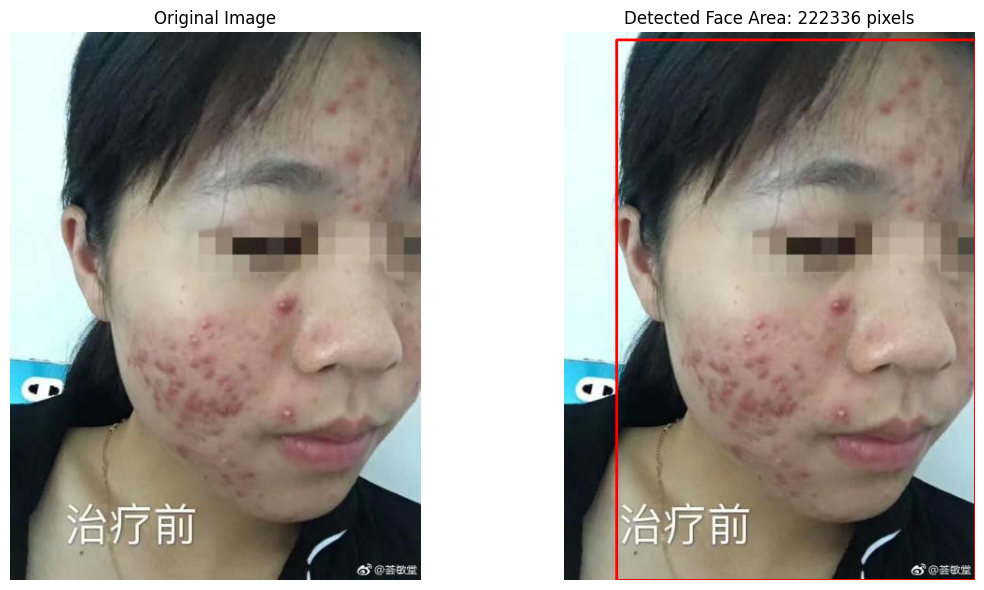

The approximate face area is 222336 square pixels


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_face_image(image_path):
    # Read the image
    img = cv2.imread(image_path)
    
    # Convert to RGB (OpenCV uses BGR by default)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Convert to grayscale for face detection
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Load face detection classifier
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_alt2.xml')
    
    # Alternative cascade for profile faces
    profile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_profileface.xml')
    
    # Detect faces
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    
    # If no frontal face detected, try profile
    if len(faces) == 0:
        faces = profile_cascade.detectMultiScale(gray, 1.1, 4)
    
    # If still no face detected, use skin color detection as fallback
    if len(faces) == 0:
        # Convert to HSV color space
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        
        # Define range for skin color in HSV
        lower_skin = np.array([0, 20, 70], dtype=np.uint8)
        upper_skin = np.array([20, 255, 255], dtype=np.uint8)
        
        # Create a binary mask
        mask = cv2.inRange(hsv, lower_skin, upper_skin)
        
        # Apply morphological operations to clean up the mask
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        
        # Find contours in the mask
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Find the largest contour (likely to be the face)
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(largest_contour)
            faces = np.array([[x, y, w, h]])
    
    # Create output image
    output = img_rgb.copy()
    face_area = 0
    
    # Draw rectangle and calculate area
    for (x, y, w, h) in faces:
        cv2.rectangle(output, (x, y), (x+w, y+h), (255, 0, 0), 2)
        face_area = w * h
    
    # Display the results
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(output)
    plt.title(f'Detected Face Area: {face_area} pixels')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return face_area

import os
random_file = np.random.choice(os.listdir('../data/set_2/train/'))
image_path = f'../data/set_2/train/{random_file}'  # Replace with your image path
face_area = process_face_image(image_path)
print(f"The approximate face area is {face_area} square pixels")

In [7]:
!pip install mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 MB 4.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 3.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 2.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 MB 3.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 MB 3.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Uninstalling protobuf-5.29.4:
      Successfully uninstalled protobuf-5.29.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [mediapipe]11 [mediapipe]trib-python]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.32.1 requires protobuf<6.0,>=5.0, b

I0000 00:00:1746216455.916436 9702660 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 88.1), renderer: Apple M3
W0000 00:00:1746216455.922078 9715906 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1746216455.927374 9715906 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Face area (approx): 2207876 pixels


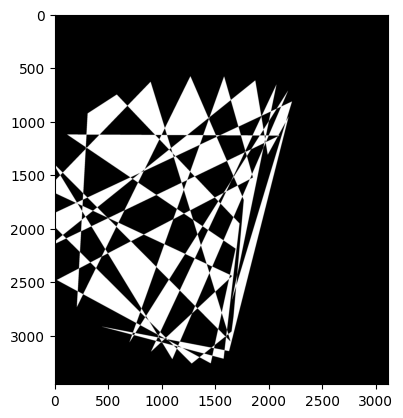

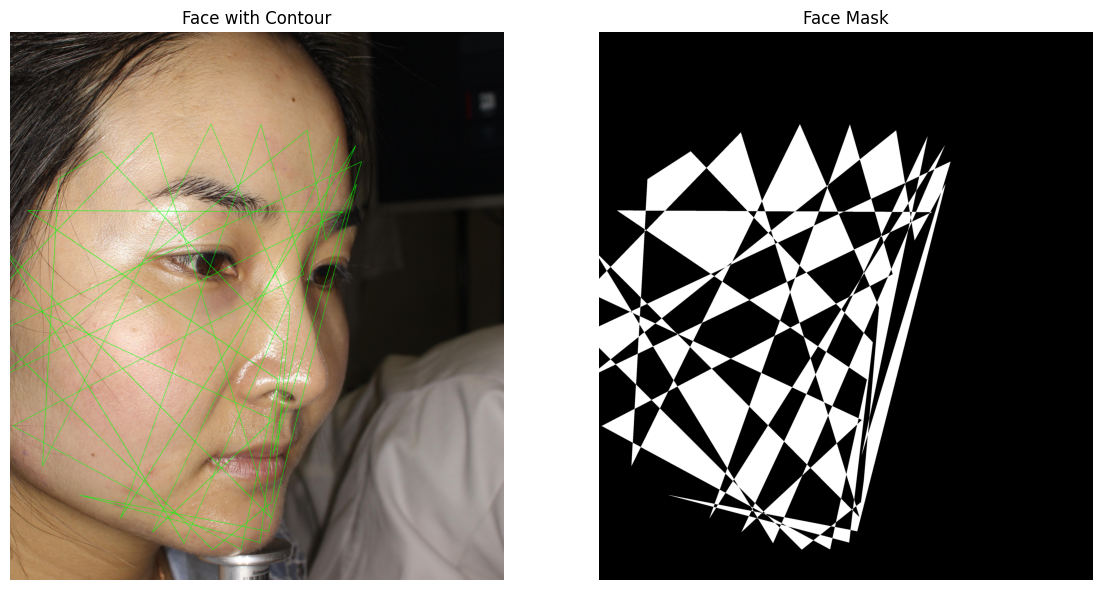

In [38]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import os

# Initialize MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True)

# Load a random image from directory
random_file = np.random.choice(os.listdir('../data/set_2/train/'))
image_path = f'../data/set_2/train/{random_file}'
image = cv2.imread(image_path)
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
results = face_mesh.process(rgb)

# Prepare mask and image dimensions
mask = np.zeros(image.shape[:2], dtype=np.uint8)
h, w = image.shape[:2]

# If faces are detected
if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        # Get (x, y) points
        points = [(int(lm.x * w), int(lm.y * h)) for lm in face_landmarks.landmark]

        # Get face oval contour points
        face_contour_indices = mp_face_mesh.FACEMESH_FACE_OVAL
        contour_pts = [points[i[0]] for i in face_contour_indices]

        # Draw filled contour on mask
        cv2.fillPoly(mask, [np.array(contour_pts, dtype=np.int32)], 255)

        # Draw contour line on a copy of the RGB image
        cv2.polylines(rgb, [np.array(contour_pts, dtype=np.int32)], isClosed=True, color=(0, 255, 0), thickness=2)

    # Calculate face area in pixels
    face_area = cv2.countNonZero(mask)
    print("Face area (approx):", face_area, "pixels")

    # Plot using matplotlib
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb)
    plt.title('Face with Contour')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Face Mask')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    face_area = process_face_image(image_path)
    print(f"The approximate face area is {face_area} square pixels")


In [41]:
from ultralytics import YOLO
model = YOLO("yolo11m.pt")  # For a small model, you can also use yolo11s.pt, yolo11m.pt, etc.

model.export(format="coreml", nms=True, imgsz=1504)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/utkarshsharma/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 38.8M/38.8M [00:13<00:00, 2.92MB/s]


Ultralytics 8.3.124 🚀 Python-3.10.16 torch-2.7.0 CPU (Apple M3)
YOLO11m summary (fused): 125 layers, 20,091,712 parameters, 0 gradients, 68.0 GFLOPs

PyTorch: starting from 'yolo11m.pt' with input shape (1, 3, 1504, 1504) BCHW and output shape(s) (1, 84, 46389) (38.8 MB)
requirements: Ultralytics requirement ['coremltools>=8.0'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 1.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [coremltools] [coremltools]

requirements: AutoUpdate success ✅ 5.0s, installed 1 package: ['coremltools>=8.0']
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



Torch version 2.7.0 has not been tested with coremltools. You may run into unexpected errors. Torch 2.5.0 is the most recent version that has been tested.
/opt/anaconda3/envs/small-llm-deploy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



CoreML: starting export with coremltools 8.3.0...


Tuple detected at graph output. This will be flattened in the converted model.
Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 81.74 passes/s]


CoreML Pipeline: starting pipeline with coremltools 8.3.0...
CoreML Pipeline: pipeline success
CoreML: export success ✅ 58.8s, saved as 'yolo11m.mlpackage' (38.8 MB)

Export complete (63.6s)
Results saved to /Users/utkarshsharma/Documents/Documents - Utkarsh’s MacBook Air/Projects/MIT AI Hackathon/MITAIHackathon/notebooks
Predict:         yolo predict task=detect model=yolo11m.mlpackage imgsz=1504  
Validate:        yolo val task=detect model=yolo11m.mlpackage imgsz=1504 data=/ultralytics/ultralytics/cfg/datasets/coco.yaml  
Visualize:       https://netron.app


'yolo11m.mlpackage'

In [42]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn

# Load a pre-trained Faster R-CNN model
model = fasterrcnn_resnet50_fpn(pretrained=True)

# If you've fine-tuned on your skin dataset, load your weights:
# model.load_state_dict(torch.load('skin_detection_model.pth'))

# Set to evaluation mode
model.eval()

# Create a dummy input for tracing
dummy_input = torch.rand(1, 3, 640, 640)

# Export to ONNX format
torch.onnx.export(
    model,                       # PyTorch model
    dummy_input,                 # Input tensor
    "skin_detection_model.onnx", # Output filebbb
    opset_version=12,            # ONNX opset version
    input_names=["input"],       # Input tensor name
    output_names=["boxes", "labels", "scores"],  # Output tensor names
    dynamic_axes={               # Support dynamic batch size
        "input": {0: "batch"},
        "boxes": {0: "batch"},
        "labels": {0: "batch"},
        "scores": {0: "batch"}
    }
)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /Users/utkarshsharma/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:42<00:00, 3.98MB/s] 


In [47]:
import torchvision
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [49]:
import torch
import torchvision

class FasterRCNNWrapper(torch.nn.Module):
    def __init__(self, model, topk=100):
        super().__init__()
        self.model = model
        self.topk = topk

    def forward(self, images):
        # Original model returns list[Dict]
        outputs = self.model(images)
        boxes = outputs[0]['boxes']         # [N, 4]
        scores = outputs[0]['scores']       # [N]
        labels = outputs[0]['labels']       # [N]

        # Pad or truncate to topk
        num_boxes = boxes.shape[0]
        if num_boxes < self.topk:
            pad_boxes = torch.zeros(self.topk - num_boxes, 4, device=boxes.device)
            pad_scores = torch.zeros(self.topk - num_boxes, device=scores.device)
            pad_labels = torch.zeros(self.topk - num_boxes, dtype=torch.int64, device=labels.device)
            boxes = torch.cat([boxes, pad_boxes], dim=0)
            scores = torch.cat([scores, pad_scores], dim=0)
            labels = torch.cat([labels, pad_labels], dim=0)
        else:
            boxes = boxes[:self.topk]
            scores = scores[:self.topk]
            labels = labels[:self.topk]

        return boxes, scores, labels

In [50]:
import coremltools as ct

# Load and wrap model
base_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
base_model.eval()
wrapped_model = FasterRCNNWrapper(base_model)
wrapped_model.eval()

# Example input
example_input = torch.rand(1, 3, 800, 800)

# Trace
traced = torch.jit.trace(wrapped_model, example_input)

# Convert to CoreML
model = ct.convert(
    traced,
    inputs=[ct.ImageType(name="image", shape=example_input.shape)],
    convert_to="mlprogram"  # required for flexible output
)

model.save("FasterRCNNWrapped.mlmodel")


Tuple detected at graph output. This will be flattened in the converted model.
Converting PyTorch Frontend ==> MIL Ops:  54%|█████▎    | 1319/2458 [00:00<00:00, 4506.28 ops/s]Saving value type of int64 into a builtin type of int32, might lose precision!
Saving value type of int64 into a builtin type of int32, might lose precision!
Saving value type of int64 into a builtin type of int32, might lose precision!
Saving value type of int64 into a builtin type of int32, might lose precision!
Saving value type of int64 into a builtin type of int32, might lose precision!
Saving value type of int64 into a builtin type of int32, might lose precision!
Saving value type of int64 into a builtin type of int32, might lose precision!
Saving value type of int64 into a builtin type of int32, might lose precision!
Saving value type of int64 into a builtin type of int32, might lose precision!
Saving value type of int64 into a builtin type of int32, might lose precision!
Converting PyTorch Frontend ==> MIL

RuntimeError: PyTorch convert function for op 'torchvision::roi_align' not implemented.

In [46]:
scripted_model = torch.jit.trace(model, dummy_input)
scripted_model.save("model_scripted.pt")

RuntimeError: Only tensors, lists, tuples of tensors, or dictionary of tensors can be output from traced functions

In [43]:
import coremltools as ct
import numpy as np

# Load the ONNX model
onnx_model = ct.converters.onnx.load("skin_detection_model.onnx")

# Define input and output descriptions
input_description = {
    "input": ct.ImageType(
        shape=(1, 3, 640, 640),  # (batch, channels, height, width)
        bias=[-0.485/0.229, -0.456/0.224, -0.406/0.225],  # ImageNet normalization
        scale=[1/0.229, 1/0.224, 1/0.225],
        color_layout="RGB"
    )
}

# Convert the model
mlmodel = ct.convert(
    onnx_model,
    inputs=input_description,
    minimum_deployment_target=ct.target.iOS15,
    convert_to="mlprogram"  # Use the newer Neural Network format
)

# Add metadata
mlmodel.author = "Your Name"
mlmodel.license = "Your License"
mlmodel.short_description = "Skin Condition Detection Model"
mlmodel.input_description["input"] = "Image of skin for condition detection"
mlmodel.output_description["boxes"] = "Bounding boxes for skin conditions"
mlmodel.output_description["labels"] = "Class labels for detected conditions"
mlmodel.output_description["scores"] = "Confidence scores for detections"

class_labels = ['mild/None', 'moderate', 'severe', 'very_severe']
mlmodel.user_defined_metadata["classes"] = ",".join(class_labels)
mlmodel.save("SkinDetectionModel.mlmodel")

AttributeError: module 'coremltools.converters' has no attribute 'onnx'

In [45]:
import coremltools as ct

# Load the ONNX model - use the direct convert method
model = ct.convert(
    "your_yolo_model.onnx",
    source="pytorch",
    inputs=[
        ct.ImageType(
            name="input", 
            shape=[1, 3, 640, 640],
            scale=1/255.0, 
            bias=[0, 0, 0]
        )
    ],
    minimum_deployment_target=ct.target.iOS15
)

# Save the model
model.save("SkinDetectionModel.mlmodel")

TypeError: Model must either be a TorchScript object (or .pt or .pth file) or an ExportedProgram object (if using torch.export based API), received: <class 'str'>

In [58]:
import sys
import os
sys.path.append(os.path.abspath('../acne-lds/model'))
sys.path.append(os.path.abspath('../acne-lds/utils'))

In [59]:
from model_ld_smoothing import AcneModel

ModuleNotFoundError: No module named 'utils.smooth_ldl'; 'utils' is not a package